# Hyperparameter Tuning Demo: Loop Closure Weight

This notebook demonstrates the physics-informed model selection procedure
for choosing `lambda_loop` (loop closure weight) as described in Appendix D.8.8.

**Workflow:**
1. Load Lorenz data from file
2. Launch a Hydra grid sweep over `loop_closure_weight` values (SLURM jobs)
3. After training completes, use the `tuning` module to select the best model

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os

# FILL THESE IN FOR YOUR OWN USE
save_dir = "/orcd/data/ekmiller/001/eisenaj/JacobianODE/lightning"
wandb_entity = "JacobianODE"

## 1. Load Lorenz Data

In [3]:
from JacobianODE.jacobians import TimeSeriesData

curr_dir = os.getcwd()
data_dir = os.path.join(curr_dir, 'example_data')
os.makedirs(data_dir, exist_ok=True)
obs_noise = 0.01
file_path = os.path.join(data_dir, f'lorenz_data_obs_noise_{obs_noise}.npz')

if os.path.exists(file_path):
    print(f"Loading data from {file_path}")
    custom_data = TimeSeriesData.load(file_path)
else:
    # Generate Lorenz data if it doesn't exist yet
    from omegaconf import OmegaConf
    from JacobianODE.jacobians import (
        load_config,
        initialize_config,
        make_trajectories,
        seed_everything,
    )

    overrides = [
        "data=dysts",
        "data.flow._target_=JacobianODE.dysts_sim.flows.Lorenz",
        f"data.postprocessing.obs_noise={obs_noise}",
        f"training.logger.save_dir={save_dir}",
    ]
    cfg = load_config(overrides=overrides)
    cfg = initialize_config(cfg)
    seed_everything(cfg.data.flow.random_state + cfg.training.run_number)
    eq, sol, dt = make_trajectories(cfg)

    custom_data = TimeSeriesData(
        values=sol['values'],
        dt=dt,
        metadata=OmegaConf.to_container(cfg.data, resolve=True),
    )
    custom_data.save(file_path)

print(f"Data shape: {custom_data.shape}  (trials={custom_data.n_trials}, time={custom_data.n_timepoints}, dims={custom_data.n_dims})")
print(f"dt: {custom_data.dt}")

Loading data from /orcd/home/002/eisenaj/code/JacobianODE/_jupyter/example_data/lorenz_data_obs_noise_0.01.npz
Data shape: (32, 1200, 3)  (trials=32, time=1200, dims=3)
dt: 0.015020517097581317


## 2. Launch Hydra Grid Sweep over `loop_closure_weight`

We use Hydra's `--multirun` mode with the SLURM launcher to submit one job
per `loop_closure_weight` value. Each job trains a full model and logs to W&B.

**The cell below generates and runs the sweep command.** After launching,
wait for all SLURM jobs to finish before proceeding to step 3.

> **NOTE**: This code assumes all hyperparameters other than `loop_closure_weight` are fixed. If you want to run multiple sweeps on different sets of hyperparameters, the code will need to be modified. Specifically, the code will need to check whether *your intended hyperparameters* have already been run, and it will subsequently need to pool all the runs specifically containing those hyperparameters. Right now, it only checks for runs with the intended `loop_closure_weight`.

In [5]:
from JacobianODE.jacobians.tuning import DEFAULT_LAMBDA_LOOP_VALUES

# Lambda values to sweep (from the tuning module defaults)
# lambda_values = DEFAULT_LAMBDA_LOOP_VALUES
lambda_values = [0]
print(f"Sweep values: {lambda_values}")

# Format for Hydra comma-separated sweep
lambda_str = ",".join(str(v) for v in lambda_values)

# Build the sweep command
sweep_cmd = (
    f"python -m JacobianODE.jacobians.run_jacobians --multirun"
    f" data=custom"
    f" data.name=LorenzCustomv2"
    f" data.postprocessing.obs_noise=0",
    f"data.postprocessing.normalize=True", # ***************
    f" data.dataset_loader._target_=JacobianODE.jacobians.custom_data.load_timeseries_data"
    f" +data.dataset_loader.file_path={file_path}"
    f" data.flow.dim={custom_data.n_dims}"
    f" training.lightning.loop_closure_weight={lambda_str}"
    f" training.logger.save_dir={save_dir}"
    f" wandb_entity={wandb_entity}"
    f" slurm=default"
)

print("\nSweep command:")
print(sweep_cmd)

Sweep values: [0]

Sweep command:
('python -m JacobianODE.jacobians.run_jacobians --multirun data=custom data.name=LorenzCustomv2 data.postprocessing.obs_noise=0', 'data.postprocessing.normalize=True', ' data.dataset_loader._target_=JacobianODE.jacobians.custom_data.load_timeseries_data +data.dataset_loader.file_path=/orcd/home/002/eisenaj/code/JacobianODE/_jupyter/example_data/lorenz_data_obs_noise_0.01.npz data.flow.dim=3 training.lightning.loop_closure_weight=0 training.logger.save_dir=/orcd/data/ekmiller/001/eisenaj/JacobianODE/lightning wandb_entity=JacobianODE slurm=default')


In [6]:
import wandb

# Check which lambda values already have completed runs on W&B
project = "LorenzCustomv2__JacobianODE"
project_path = f"{wandb_entity}/{project}" if wandb_entity else project

api = wandb.Api()
try:
    existing_runs = api.runs(project_path)
    print(f"Found {len(existing_runs)} existing runs in {project_path}")
except Exception as e:
    print(f"Could not query project (may not exist yet): {e}")
    existing_runs = []

# Identify lambda values that already have finished runs
already_run = []
remaining_lambdas = []
for lam in lambda_values:
    matching = [
        run for run in existing_runs
        if 'training' in run.config
        and 'lightning' in run.config['training']
        and abs(run.config['training']['lightning'].get('loop_closure_weight', -1) - lam) < 1e-10
        and run.state == 'finished'
    ]
    if matching:
        already_run.append(lam)
        print(f"  lambda={lam}: already completed (run_id={matching[0].id})")
    else:
        remaining_lambdas.append(lam)

if already_run:
    print(f"\nSkipping {len(already_run)} already-completed values: {already_run}")

if remaining_lambdas:
    # Rebuild sweep command with only the remaining lambda values
    lambda_str = ",".join(str(v) for v in remaining_lambdas)
    sweep_cmd = (
        f"python -m JacobianODE.jacobians.run_jacobians --multirun"
        f" data=custom"
        f" data.name=LorenzCustom"
        f" data.postprocessing.obs_noise=0"
        f" data.dataset_loader._target_=JacobianODE.jacobians.custom_data.load_timeseries_data"
        f" +data.dataset_loader.file_path={file_path}"
        f" data.flow.dim={custom_data.n_dims}"
        f" training.lightning.loop_closure_weight={lambda_str}"
        f" training.logger.save_dir={save_dir}"
        f" wandb_entity={wandb_entity}"
        f" slurm=default"
    )
    print(f"\nUpdated sweep command ({len(remaining_lambdas)} remaining):")
    print(sweep_cmd)
else:
    sweep_cmd = None
    print("\nAll lambda values already have finished runs -- no sweep needed!")

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /home/eisenaj/.netrc.


Could not query project (may not exist yet): Could not find project LorenzCustomv2__JacobianODE

Updated sweep command (1 remaining):
python -m JacobianODE.jacobians.run_jacobians --multirun data=custom data.name=LorenzCustom data.postprocessing.obs_noise=0 data.dataset_loader._target_=JacobianODE.jacobians.custom_data.load_timeseries_data +data.dataset_loader.file_path=/orcd/home/002/eisenaj/code/JacobianODE/_jupyter/example_data/lorenz_data_obs_noise_0.01.npz data.flow.dim=3 training.lightning.loop_closure_weight=0 training.logger.save_dir=/orcd/data/ekmiller/001/eisenaj/JacobianODE/lightning wandb_entity=JacobianODE slurm=default


In [7]:
# Launch the sweep (submits SLURM jobs)
# Uncomment the line below to actually run:
if sweep_cmd is not None:
    !{sweep_cmd}
else:
    print("No sweep to launch — all runs already completed.")

Sweep output dir : multirun/2026-02-25/19-51-18
[2026-02-25 19:51:18,647][HYDRA] Submitit 'slurm' sweep output dir : multirun/2026-02-25/19-51-18
[2026-02-25 19:51:18,649][HYDRA] 	#0 : data=custom data.name=LorenzCustom data.postprocessing.obs_noise=0 data.dataset_loader._target_=JacobianODE.jacobians.custom_data.load_timeseries_data +data.dataset_loader.file_path=/orcd/home/002/eisenaj/code/JacobianODE/_jupyter/example_data/lorenz_data_obs_noise_0.01.npz data.flow.dim=3 training.lightning.loop_closure_weight=0 training.logger.save_dir=/orcd/data/ekmiller/001/eisenaj/JacobianODE/lightning wandb_entity=JacobianODE slurm=default
Traceback (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/orcd/home/002/eisenaj/code/JacobianODE/JacobianODE/jacobians/run_jacobians.py", line 131, in <module>
    train_jacobians()
  File "/orcd/home/002/eisenaj/code/JacobianODE/.venv/lib64/python3.12/site-packages/hydra/m

## 3. Select the Best Model (Post-hoc)

After all sweep jobs finish, collect the W&B run IDs and use the tuning module
to apply the physics-informed selection criteria:

- **C1 (one-step error)**: model must beat persistence baseline
- **C2 (loop closure)**: loop closure loss must be below `sqrt(n_dims)`
- **C3 (eigenvalue)**: fraction of fast eigenvalues must be below threshold

With relaxation rules when criteria conflict.

### 3a. Collect W&B Run IDs

Find the runs from the sweep. You can get these from the W&B UI or
use the W&B API to query by project and sweep parameters.

In [9]:
import wandb

# Query W&B for the sweep runs
project = "LorenzCustom__JacobianODE"
project_path = f"{wandb_entity}/{project}" if wandb_entity else project

api = wandb.Api()
try:
    all_runs = api.runs(project_path)
    print(f"Found {len(all_runs)} total runs in {project_path}")
except Exception as e:
    print(f"Could not query project: {e}")
    all_runs = []

Found 20 total runs in JacobianODE/LorenzCustom__JacobianODE


In [10]:
# Check for crashed/failed runs and delete them from W&B
crashed_lambdas = []
for run in all_runs:
    if run.state in ('crashed', 'failed'):
        lam = None
        if ('training' in run.config
            and 'lightning' in run.config['training']):
            lam = run.config['training']['lightning'].get('loop_closure_weight', None)
        print(f"CRASHED: run_id={run.id} (lambda={lam}) -- deleting from W&B")
        run.delete()
        if lam is not None:
            crashed_lambdas.append(lam)

if crashed_lambdas:
    # Check which crashed lambdas still have a finished run available
    needs_rerun = []
    for lam in crashed_lambdas:
        has_finished = any(
            run for run in all_runs
            if run.state == 'finished'
            and 'training' in run.config
            and 'lightning' in run.config['training']
            and abs(run.config['training']['lightning'].get('loop_closure_weight', -1) - lam) < 1e-10
        )
        if not has_finished:
            needs_rerun.append(lam)

    print(f"\nDeleted {len(crashed_lambdas)} crashed run(s).")
    if needs_rerun:
        print(f"Re-run the sweep to retry lambda={needs_rerun}")
    else:
        print("All crashed lambdas have other finished runs -- no re-runs needed.")
else:
    print("No crashed runs found.")

# Match runs to lambda values by their loop_closure_weight config
sweep_run_ids = []
sweep_lambdas = []

for lam in lambda_values:
    matching = [
        run for run in all_runs
        if 'training' in run.config
        and 'lightning' in run.config['training']
        and abs(run.config['training']['lightning'].get('loop_closure_weight', -1) - lam) < 1e-10
        and run.state == 'finished'
    ]
    if matching:
        # Take the most recent run for this lambda
        best_run = matching[0]
        sweep_run_ids.append(best_run.id)
        sweep_lambdas.append(lam)
        print(f"lambda={lam}: run_id={best_run.id} ({best_run.name})")
    else:
        print(f"lambda={lam}: NO MATCHING RUN FOUND")

print(f"\nFound {len(sweep_run_ids)} / {len(lambda_values)} sweep runs")

No crashed runs found.
lambda=0: run_id=4kqsc0j2 (MLP__hidden_dim_[256, 1024, 2048, 2048]__num_layers_4__residuals_False__dropout_0.0__activation_silu__batch_size_16__optimizer_AdamW__optimizer_kwargs_{'lr': 0.0001, 'weight_decay': 0.0001}__use_scheduler_True__min_lr_1e-06__k_scale_1__gradient_clip_val_1.0__gradient_clip_algorithm_norm__alpha_teacher_forcing_1__teacher_forcing_annealing_True__gamma_teacher_forcing_0.999__teacher_forcing_update_interval_5__teacher_forcing_steps_1__min_alpha_teacher_forcing_0__alpha_validation_0__obs_noise_scale_0.0000__jac_penalty_0.0__jac_norm_ord_fro__loop_closure_training_True__loop_closure_weight_0__n_loop_pts_20__mix_trajectories_True__loop_closure_interp_pts_20__loop_closure_int_method_Trapezoid__jacobianODEint_kwargs_{'traj_init_steps': 15, 'inner_path': 'line', 'inner_N': 20, 'interp_pts': 4}__log_interval_100__trajectory_training_True__use_base_deriv_pt_False__direct_True__loss_func_mse__data_type_custom__obs_noise_0.0000__filter_data_False__lo

### 3b. Run Model Selection

Load each checkpoint, compute diagnostic metrics, and apply the selection algorithm.

In [16]:
import torch
import numpy as np
from JacobianODE.jacobians import (
    load_config,
    initialize_config,
    make_trajectories,
    postprocess_data,
    create_dataloaders,
    seed_everything,
    load_run,
    load_checkpoint,
)
from JacobianODE.jacobians.tuning.criteria import (
    compute_all_diagnostics,
    DiagnosticMetrics,
)
from JacobianODE.jacobians.tuning.selection import select_best_model

# ----------------------------------------
# Prepare data for evaluation
# ----------------------------------------
common_overrides = [
    "data=custom",
    "data.name=LorenzCustom",
    "data.postprocessing.obs_noise=0",
    "data.postprocessing.normalize=True",
    f"training.logger.save_dir={save_dir}",
    f"wandb_entity={wandb_entity}",
]

cfg = load_config(overrides=common_overrides)
cfg = initialize_config(cfg, data_dim=custom_data.n_dims)

seed_everything(cfg.data.flow.random_state + cfg.training.run_number)
eq, sol, dt = make_trajectories(cfg, data=custom_data.values, dt=custom_data.dt)
values = postprocess_data(cfg, sol['values'])
train_dataloader, val_dataloader, test_dataloader, trajs = create_dataloaders(cfg, values)

# Persistence baseline from training data
train_trajs = trajs['train_trajs'].sequence
n_dims = custom_data.n_dims

print(f"Data dimensionality: {n_dims}")
print(f"sqrt(n_dims) = {np.sqrt(n_dims):.4f}  (C2 threshold)")
print(f"dt = {dt:.6f}")

Data dimensionality: 3
sqrt(n_dims) = 1.7321  (C2 threshold)
dt = 0.015021


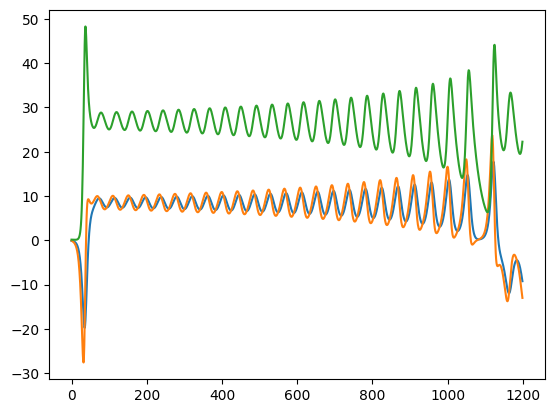

In [17]:
import matplotlib.pyplot as plt
plt.plot(train_trajs[0])

In [11]:
# ----------------------------------------
# Load each model and compute diagnostics
# ----------------------------------------
device = 'cuda' if torch.cuda.is_available() else 'cpu'
n_batches = 100
all_diagnostics = []

for i, run_id in enumerate(sweep_run_ids):
    print(f"\n[{i+1}/{len(sweep_run_ids)}] Loading run {run_id} (lambda={sweep_lambdas[i]})")

    # Load run and checkpoint
    generate_data = (i == 0)  # Only generate data for first run
    run_obj, run_cfg, _, _, _, _, val_dl, _, _, lit_model = load_run(
        project_path, run_id=run_id, save_dir=save_dir,
        generate_data=generate_data, dt=dt, verbose=False,
    )
    if generate_data:
        eval_val_dl = val_dl  # Reuse for all models

    load_checkpoint(run_obj, run_cfg, lit_model, save_dir=save_dir, verbose=False)
    lit_model.eval()
    lit_model = lit_model.to(device)

    # Compute all diagnostic metrics
    metrics = compute_all_diagnostics(
        lit_model, eval_val_dl, dt,
        n_batches=n_batches, use_loop_closure=True,
    )
    all_diagnostics.append(metrics)

    print(f"  one_step_error:          {metrics.one_step_error:.6f}")
    print(f"  loop_closure_loss:       {metrics.loop_closure_loss:.6f}")
    print(f"  fast_eigenvalue_fraction: {metrics.fast_eigenvalue_fraction:.6f}")
    print(f"  trajectory_val_loss:     {metrics.trajectory_val_loss:.6f}")

    # Free GPU memory
    lit_model.cpu()
    torch.cuda.empty_cache()


[1/9] Loading run 4kqsc0j2 (lambda=0)
  one_step_error:          0.000244
  loop_closure_loss:       333.603288
  fast_eigenvalue_fraction: 0.000000
  trajectory_val_loss:     0.002888

[2/9] Loading run 6a623lnb (lambda=1e-06)
  one_step_error:          0.003056
  loop_closure_loss:       360.393942
  fast_eigenvalue_fraction: 0.000000
  trajectory_val_loss:     0.088217

[3/9] Loading run kcdjd1qq (lambda=1e-05)
  one_step_error:          0.000245
  loop_closure_loss:       65.552438
  fast_eigenvalue_fraction: 0.000000
  trajectory_val_loss:     0.004082

[4/9] Loading run u6504cdg (lambda=0.0001)
  one_step_error:          0.000110
  loop_closure_loss:       8.088699
  fast_eigenvalue_fraction: 0.000000
  trajectory_val_loss:     0.001790

[5/9] Loading run kya4cr5p (lambda=0.001)
  one_step_error:          0.001119
  loop_closure_loss:       5.848559
  fast_eigenvalue_fraction: 0.000000
  trajectory_val_loss:     0.027034

[6/9] Loading run di439p7x (lambda=0.01)
  one_step_error

In [12]:
# ----------------------------------------
# Run model selection
# ----------------------------------------
result = select_best_model(
    all_diagnostics,
    persistence_baseline=persistence,
    n_dims=n_dims,
    eigenvalue_threshold=0.001,
    use_loop_closure=True,
)

print("=" * 60)
print("MODEL SELECTION RESULT")
print("=" * 60)
print(f"Best lambda:    {sweep_lambdas[result.best_index]}")
print(f"Best run ID:    {sweep_run_ids[result.best_index]}")
print(f"Best traj loss: {result.best_metrics.trajectory_val_loss:.6f}")
print(f"\nCriteria applied (after relaxation): {result.criteria_applied}")
print(f"Surviving models: {len(result.surviving_indices)} / {len(all_diagnostics)}")
print(f"Surviving lambda values: {[sweep_lambdas[i] for i in result.surviving_indices]}")

print("\nExclusion details (before relaxation):")
for criterion, excluded in result.exclusion_details.items():
    if excluded:
        excluded_lambdas = [sweep_lambdas[i] for i in excluded]
        print(f"  {criterion}: excluded lambdas {excluded_lambdas}")
    else:
        print(f"  {criterion}: no exclusions")

MODEL SELECTION RESULT
Best lambda:    0.01
Best run ID:    di439p7x
Best traj loss: 0.003420

Criteria applied (after relaxation): ['C1', 'C2', 'C3']
Surviving models: 4 / 9
Surviving lambda values: [0.01, 0.1, 1, 10]

Exclusion details (before relaxation):
  C1: no exclusions
  C2: excluded lambdas [0, 1e-06, 1e-05, 0.0001, 0.001]
  C3: no exclusions


### 3c. Visualize Selection

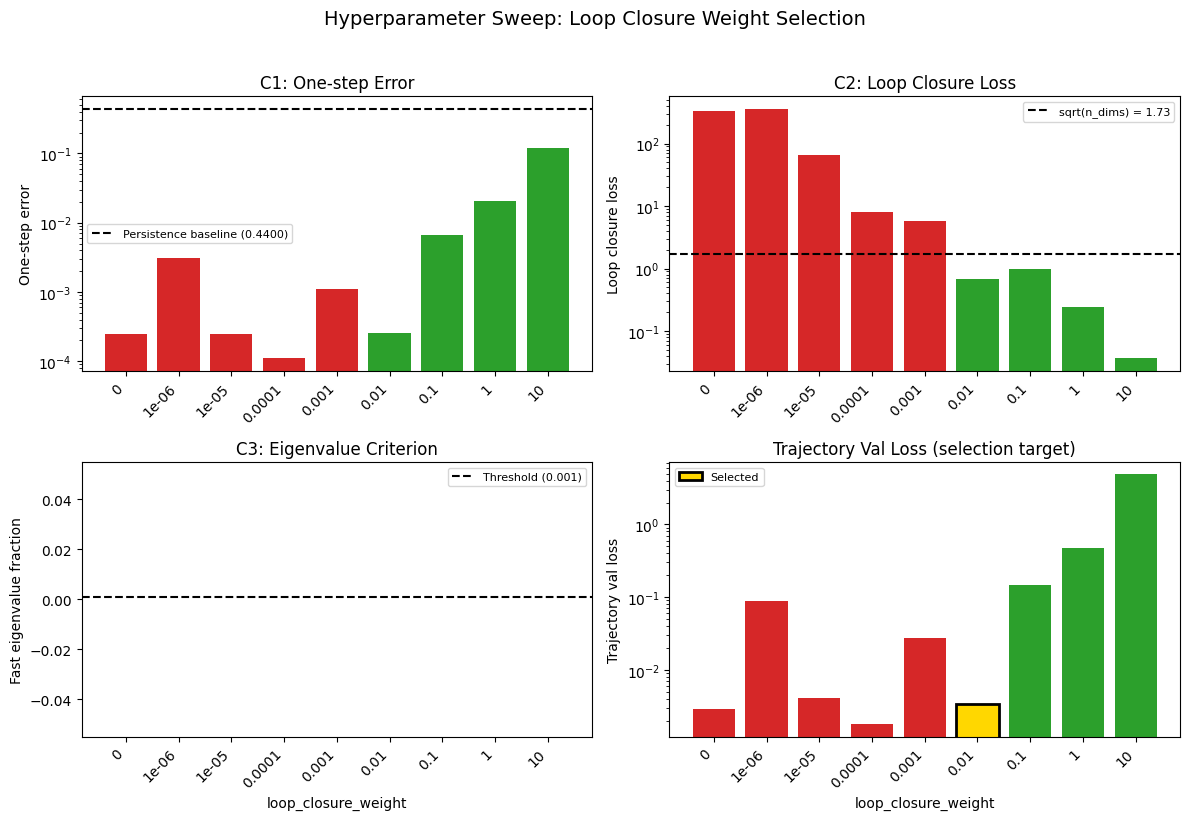

In [15]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Extract metrics arrays
one_step_errors = [m.one_step_error for m in all_diagnostics]
loop_closure_losses = [m.loop_closure_loss for m in all_diagnostics]
eig_fracs = [m.fast_eigenvalue_fraction for m in all_diagnostics]
traj_losses = [m.trajectory_val_loss for m in all_diagnostics]

# Color: green for survivors, red for excluded, star for best
colors = ['tab:green' if i in result.surviving_indices else 'tab:red'
          for i in range(len(all_diagnostics))]

x_labels = [str(v) for v in sweep_lambdas]
x_pos = range(len(sweep_lambdas))

# Panel 1: One-step error vs persistence baseline (C1)
axes[0, 0].bar(x_pos, one_step_errors, color=colors)
axes[0, 0].axhline(y=persistence, color='k', linestyle='--', label=f'Persistence baseline ({persistence:.4f})')
axes[0, 0].set_ylabel('One-step error')
axes[0, 0].set_title('C1: One-step Error')
axes[0, 0].set_xticks(x_pos)
axes[0, 0].set_xticklabels(x_labels, rotation=45, ha='right')
axes[0, 0].legend(fontsize=8)
axes[0, 0].set_yscale('log')

# Panel 2: Loop closure loss vs sqrt(n_dims) (C2)
axes[0, 1].bar(x_pos, loop_closure_losses, color=colors)
axes[0, 1].axhline(y=np.sqrt(n_dims), color='k', linestyle='--', label=f'sqrt(n_dims) = {np.sqrt(n_dims):.2f}')
axes[0, 1].set_ylabel('Loop closure loss')
axes[0, 1].set_title('C2: Loop Closure Loss')
axes[0, 1].set_xticks(x_pos)
axes[0, 1].set_xticklabels(x_labels, rotation=45, ha='right')
axes[0, 1].legend(fontsize=8)
axes[0, 1].set_yscale('log')

# Panel 3: Fast eigenvalue fraction (C3)
axes[1, 0].bar(x_pos, eig_fracs, color=colors)
axes[1, 0].axhline(y=0.001, color='k', linestyle='--', label='Threshold (0.001)')
axes[1, 0].set_ylabel('Fast eigenvalue fraction')
axes[1, 0].set_title('C3: Eigenvalue Criterion')
axes[1, 0].set_xticks(x_pos)
axes[1, 0].set_xticklabels(x_labels, rotation=45, ha='right')
axes[1, 0].set_xlabel('loop_closure_weight')
axes[1, 0].legend(fontsize=8)

# Panel 4: Trajectory val loss (selection target)
axes[1, 1].bar(x_pos, traj_losses, color=colors)
if result.best_index is not None:
    axes[1, 1].bar(result.best_index, traj_losses[result.best_index],
                    color='gold', edgecolor='black', linewidth=2, label='Selected')
axes[1, 1].set_ylabel('Trajectory val loss')
axes[1, 1].set_title('Trajectory Val Loss (selection target)')
axes[1, 1].set_xticks(x_pos)
axes[1, 1].set_xticklabels(x_labels, rotation=45, ha='right')
axes[1, 1].set_xlabel('loop_closure_weight')
axes[1, 1].legend(fontsize=8)
axes[1, 1].set_yscale('log')

fig.suptitle('Hyperparameter Sweep: Loop Closure Weight Selection', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 3d. Load the Best Model for Downstream Use

In [16]:
# Load the selected best model
best_run_id = sweep_run_ids[result.best_index]
best_lambda = sweep_lambdas[result.best_index]

print(f"Loading best model: run_id={best_run_id}, lambda={best_lambda}")

run_obj, run_cfg, eq, _, _, _, _, _, _, lit_model = load_run(
    project_path, run_id=best_run_id, save_dir=save_dir,
    no_noise=True, generate_data=True, verbose=True,
)
load_checkpoint(run_obj, run_cfg, lit_model, save_dir=save_dir, verbose=True)
lit_model.eval()

print(f"\nBest model loaded and ready for analysis.")
print(lit_model)

Loading best model: run_id=di439p7x, lambda=0.01

Best model loaded and ready for analysis.
LitMLP(
  (model): MLP(
    (layers): ModuleList(
      (0): Linear(in_features=3, out_features=256, bias=True)
      (1): SiLU()
      (2): Linear(in_features=256, out_features=1024, bias=True)
      (3): SiLU()
      (4): Linear(in_features=1024, out_features=2048, bias=True)
      (5): SiLU()
      (6): Linear(in_features=2048, out_features=2048, bias=True)
      (7): SiLU()
      (8): Linear(in_features=2048, out_features=9, bias=True)
    )
  )
  (criterion): MSELoss()
)


Overall R2 score: 0.9390617609024048


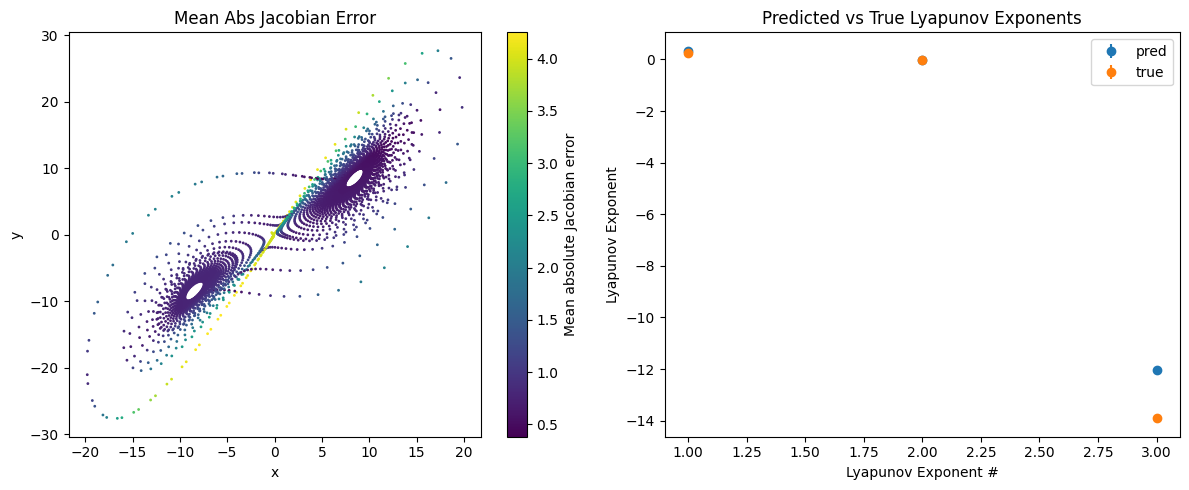

In [17]:
%autoreload 2
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from JacobianODE.jacobians.analysis import compute_lyaps
from JacobianODE.dysts_sim.flows import Lorenz

# True dynamics for Jacobian comparison (Lorenz generates this custom data)
eq_true = Lorenz() if eq is None else eq

# 2. Get test data and move to GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
lit_model = lit_model.to(device)
test_batch = trajs["test_trajs"].sequence.to(device)

# 3. Predicted Jacobians (model expects normalized input)
with torch.no_grad():
    jacs_pred = torch.stack([
        lit_model.compute_jacobians(test_batch[i].type(lit_model.dtype))
        for i in range(test_batch.shape[0])
    ]).cpu()

# 4. True Jacobians (denormalize for eq: x_orig = x_norm * sigma + mu)
def _to_numpy(x):
    return x.cpu().numpy() if isinstance(x, torch.Tensor) else np.asarray(x)

x_orig = (
    test_batch.cpu().numpy() * _to_numpy(lit_model.sigma) + _to_numpy(lit_model.mu)
).astype(np.float64)
n_trials, n_time, n_dim = x_orig.shape
t_indices = np.arange(n_time)*dt
jacs_true_np = eq_true.jac(x_orig, t_indices)
jacs_true = torch.from_numpy(jacs_true_np).float()

# 5. Compute error and plot
print(f"Overall R2 score: {r2_score(jacs_pred.flatten(), jacs_true.flatten())}")
jac_error = (jacs_pred - jacs_true).abs()
error_per_point = jac_error.mean(dim=(2, 3)).numpy()

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# First subplot: scatter of mean absolute Jacobian error
sc = axs[0].scatter(
    x_orig[:, :, 0].flatten(),
    x_orig[:, :, 1].flatten(),
    c=error_per_point.flatten(),
    s=1,
    cmap="viridis",
)
cb = fig.colorbar(sc, ax=axs[0], label="Mean absolute Jacobian error")
axs[0].set_title("Mean Abs Jacobian Error")
axs[0].set_xlabel("x")
axs[0].set_ylabel("y")

# Second subplot: Lyapunov spectrum
lyaps_pred = compute_lyaps(torch.linalg.matrix_exp(jacs_pred*dt), dt=dt)
lyaps_true = compute_lyaps(torch.linalg.matrix_exp(jacs_true*dt), dt=dt)
# make the size of the points bigger
# add error bars on the estimated lyaps (standard error of the mean)
lyap_pred_mean = lyaps_pred.mean(dim=0)
lyap_pred_sem = lyaps_pred.std(dim=0) / np.sqrt(lyaps_pred.shape[0])
lyap_true_mean = lyaps_true.mean(dim=0)
lyap_true_sem = lyaps_true.std(dim=0) / np.sqrt(lyaps_true.shape[0])

x_vals = np.arange(1, lyap_pred_mean.shape[0] + 1)
# capsize=0 removes horizontal caps so error bars are purely vertical (along y)
axs[1].errorbar(x_vals, lyap_pred_mean, yerr=lyap_pred_sem, fmt='.', label='pred', markersize=12, capsize=0)
axs[1].errorbar(x_vals, lyap_true_mean, yerr=lyap_true_sem, fmt='.', label='true', markersize=12, capsize=0)
axs[1].set_xlabel("Lyapunov Exponent #")
axs[1].set_ylabel("Lyapunov Exponent")
axs[1].set_title("Predicted vs True Lyapunov Exponents")
axs[1].legend()

plt.tight_layout()
plt.show()